<a href="https://colab.research.google.com/github/alopezdelgado/cheminformatics/blob/main/SMILES_informer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Enter SMILES string (e.g., CCO, CC(=O)Oc1ccccc1C(=O)O): CC(=O)Oc1ccccc1C(=O)O

--- Analysis for SMILES: CC(=O)Oc1ccccc1C(=O)O ---
Molecular Weight: 180.16
LogP (hydrophobicity proxy): 1.31
TPSA (Polar Surface Area): 63.60
Molecule Image:


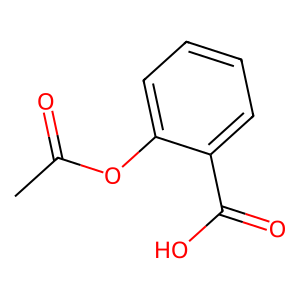

In [9]:
!pip install rdkit
import requests
from io import BytesIO
from rdkit import Chem
from rdkit.Chem import Descriptors, Draw
from rdkit.Chem import AllChem as rdMolDescriptors # Import AllChem for CalcTPSA
from IPython.display import Image, display

def analyze_molecule_from_smiles():
    smiles = input("Enter SMILES string (e.g., CCO, CC(=O)Oc1ccccc1C(=O)O): ")

    if smiles:
        mol = Chem.MolFromSmiles(smiles)
        if mol is None:
            print(f"Could not create RDKit molecule from SMILES: {smiles}. Please check the SMILES string.")
            return

        # For display purposes, we can use the SMILES string as the 'name'
        molecule_display_name = smiles

        # Calculate properties
        mw = Descriptors.MolWt(mol)
        logp = Descriptors.MolLogP(mol)
        tpsa = rdMolDescriptors.CalcTPSA(mol) # Corrected call for TPSA

        print(f"\n--- Analysis for SMILES: {molecule_display_name} ---")
        print(f"Molecular Weight: {mw:.2f}")
        print(f"LogP (hydrophobicity proxy): {logp:.2f}")
        print(f"TPSA (Polar Surface Area): {tpsa:.2f}")

        # Generate and display image
        img = Draw.MolToImage(mol, size=(300, 300))
        print("Molecule Image:")
        display(img)
    else:
        print("No SMILES string provided. Failed to analyze molecule.")

# Run the analysis
analyze_molecule_from_smiles()